In [1]:
# Student Name: Amir Gharghabi
# Student ID: 810102217
# HW: 2
# Q: 6

In [2]:
import numpy as np
import matplotlib.pyplot as plt

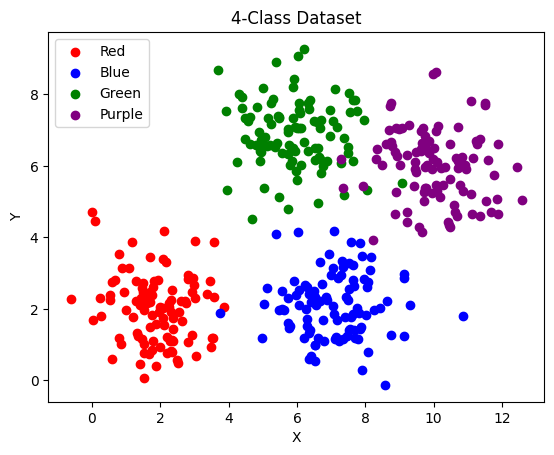

In [3]:
# Generate random data for each class
np.random.seed(42)

# Class 1
class1_x = np.random.normal(2, 1, 100)
class1_y = np.random.normal(2, 1, 100)

# Class 2
class2_x = np.random.normal(7, 1, 100)
class2_y = np.random.normal(2, 1, 100)

# Class 3
class3_x = np.random.normal(6, 1, 100)
class3_y = np.random.normal(7, 1, 100)

# Class 4
class4_x = np.random.normal(10, 1, 100)
class4_y = np.random.normal(6, 1, 100)

# Plot the data
plt.scatter(class1_x, class1_y, color='red', label='Red')
plt.scatter(class2_x, class2_y, color='blue', label='Blue')
plt.scatter(class3_x, class3_y, color='green', label='Green')
plt.scatter(class4_x, class4_y, color='purple', label='Purple')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('4-Class Dataset')
plt.legend()
plt.show()

In [4]:
# Combine data points into a single feature matrix and label array
X = np.vstack((np.column_stack((class1_x, class1_y)),
               np.column_stack((class2_x, class2_y)),
               np.column_stack((class3_x, class3_y)),
               np.column_stack((class4_x, class4_y))))
y = np.hstack((np.zeros(100), np.ones(100), np.ones(100)*2, np.ones(100)*3))


In [5]:
# Define a function to calculate Euclidean distance
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

# Implement KNN classifier
def knn_classifier(X_train, y_train, x_test, k):
    distances = np.array([euclidean_distance(x, x_test) for x in X_train])
    indices = np.argsort(distances)[:k]
    labels = y_train[indices]
    unique_labels, counts = np.unique(labels, return_counts=True)
    predicted_label = unique_labels[np.argmax(counts)]
    return predicted_label

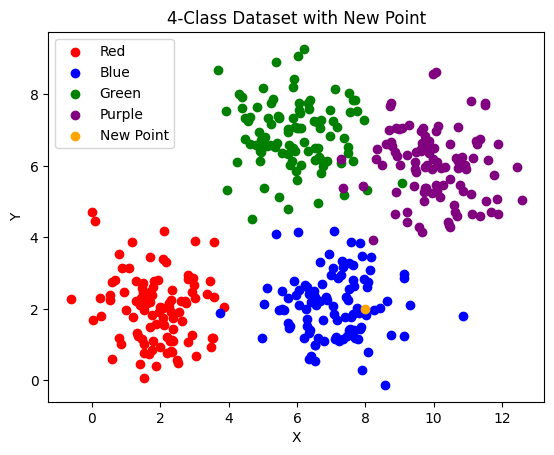

The new point is classified as Blue


In [6]:
# Test the KNN classifier with a new point
new_point = np.array([8, 2])
k = 15
predicted_class = knn_classifier(X, y, new_point, k)

# Define class names
class_colors = ['Red', 'Blue', 'Green', 'Purple']

# Plot the data with the new point and its predicted class
plt.scatter(class1_x, class1_y, color='red', label='Red')
plt.scatter(class2_x, class2_y, color='blue', label='Blue')
plt.scatter(class3_x, class3_y, color='green', label='Green')
plt.scatter(class4_x, class4_y, color='purple', label='Purple')
plt.scatter(new_point[0], new_point[1], color='orange', label='New Point')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('4-Class Dataset with New Point')
plt.legend()
plt.show()

print("The new point is classified as "+ class_colors[int(predicted_class)])

In [7]:
class KNNClassifier:
    def __init__(self):
        self.X_train = None
        self.y_train = None
    
    def euclidean_distance(self, p1, p2):
        return np.sqrt(np.sum((p1 - p2) ** 2))
    
    def predict(self, x_test, k):
        distances = np.array([self.euclidean_distance(x, x_test) for x in self.X_train])
        indices = np.argsort(distances)[:k]
        labels = self.y_train[indices]
        unique_labels, counts = np.unique(labels, return_counts=True)
        predicted_label = unique_labels[np.argmax(counts)]
        return predicted_label
    
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
    
    def scatter_plot_new_point(self, new_point):#, predicted_class):
        # Define a list of colors for each class
        class_colors = ['red', 'blue', 'green', 'purple']
        # Scatter plot the existing points with different colors for each class
        plt.scatter(self.X_train[:, 0], self.X_train[:, 1], c=[class_colors[int(label)] for label in self.y_train])#, label='Training Points')
        # Scatter plot the new point with orange color
        plt.scatter(new_point[0], new_point[1], color='orange', label='New Point')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Scatter plot')
        plt.legend()
        plt.show()


In [8]:
KNN = KNNClassifier()
KNN.fit(X, y)
k = 5
# Define class names
new_point = np.array([8, 2])
KNN.predict(new_point, k)
class_colors = ['Red', 'Blue', 'Green', 'Purple']
print("Predicted class is: " + class_colors[int(KNN.predict(new_point, k))])


Predicted class is: Blue


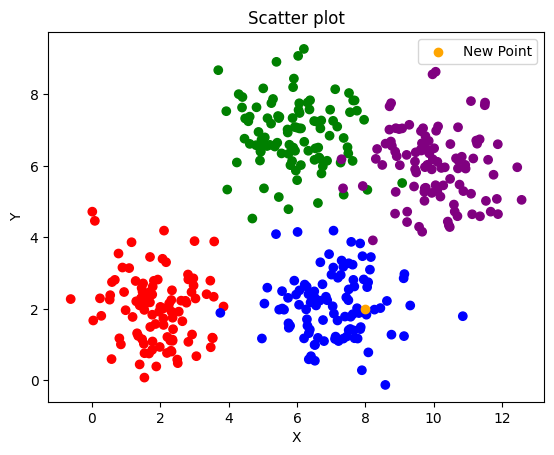

In [128]:
# Plot the new point amongst other classes
KNN.scatter_plot_new_point(new_point)

In [9]:
from sklearn.datasets import load_iris

In [10]:
# Load the Iris dataset
iris = load_iris()

# Access the data, target, and feature names
X = iris.data  # Features
y = iris.target  # Target variable
feature_names = iris.feature_names  # Feature names
target_names = iris.target_names  # Target names

# Print the shape of the data
print("Shape of data:", X.shape)
print("Shape of label:", y.shape)
print("")
print("First sample is as follows:")
print("Features:", X[0])
print("Target:", y[0])

Shape of data: (150, 4)
Shape of label: (150,)

First sample is as follows:
Features: [5.1 3.5 1.4 0.2]
Target: 0


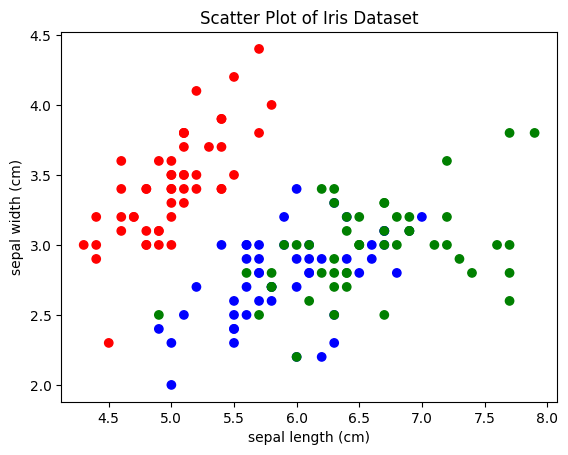

In [133]:
feature_names = iris.feature_names  # Feature names
target_names = iris.target_names  # Target names

# Create a scatter plot
plt.scatter(X[:, 0], X[:, 1], c=[class_colors[int(label)] for label in y], cmap='viridis')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Scatter Plot of Iris Dataset')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle


In [17]:
#X, y = shuffle(X, y, random_state=42)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8)

# Print the shape of the training and validation sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train: (120, 4)
Shape of X_val: (30, 4)
Shape of y_train: (120,)
Shape of y_val: (30,)


In [18]:
IrisKNN = KNNClassifier()
IrisKNN.fit(X_train, y_train)
k = 10

y_val_pred = [IrisKNN.predict(x, k) for x in X_val]
y_train_pred = [IrisKNN.predict(x, k) for x in X_train]

def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

train_accuracy = calculate_accuracy(y_train, y_train_pred)
val_accuracy = calculate_accuracy(y_val, y_val_pred)

print(f"Accuracy for k=" + str(k) + ": " + str(train_accuracy))
print(f"Accuracy for k=" + str(k) + ": " + str(val_accuracy))

Accuracy for k=10: 0.9666666666666667
Accuracy for k=10: 0.9666666666666667


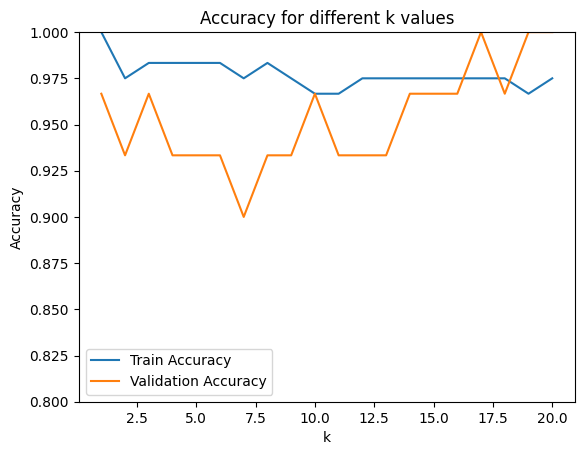

In [19]:
import matplotlib.pyplot as plt

train_accuracies = []
val_accuracies = []

k_values = range(1, 21)  # Range of k values from 1 to 20

for k in k_values:
    y_val_pred = [IrisKNN.predict(x, k) for x in X_val]
    y_train_pred = [IrisKNN.predict(x, k) for x in X_train]

    train_accuracy = calculate_accuracy(y_train, y_train_pred)
    val_accuracy = calculate_accuracy(y_val, y_val_pred)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    #print("Accuracy for k={}: Train: {:.2f}, Validation: {:.2f}".format(k, train_accuracy, val_accuracy))

# Plotting the accuracies
plt.plot(k_values, train_accuracies, label='Train Accuracy')
plt.plot(k_values, val_accuracies, label='Validation Accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy for different k values')
plt.ylim(0.8, 1.0)  # Set y-axis limits to display accuracy values from 0.8 to 1.0
plt.legend()
plt.show()

In [ ]:
# End of Q6